In [2]:
import numpy as np
from scipy.stats import gamma
import matplotlib.pyplot as plt
import math 
from scipy.special import genlaguerre as genlag
from numpy.polynomial import Laguerre

%matplotlib notebook
%pylab

Using matplotlib backend: nbAgg
Populating the interactive namespace from numpy and matplotlib


C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\magics\pylab.py:160: UserWarning: pylab import has clobbered these variables: ['gamma', 're']
`%matplotlib` prevents importing * from pylab and numpy
  "\n`%matplotlib` prevents importing * from pylab and numpy"


# Analytical solution

In [26]:
aa=1.4
b=7.0
Nx=150
#Nx=21
h_bar=1.9e5 #in KJ.A.mol-1.c-2
m=3.36e11# in kj.mol-1.c^-2 (is a reduced mas) (I multiplied by the inverse of the Avogadro constante A ) for 4He
#m=2.59e11#  for 3He
a=2.760# in 1/A a means alpha
De=22.987#in Kj/mol
re=1.693#in A
Lambda = np.sqrt((2*De*m))/(a*h_bar) # in (Kj/mol)^2
r=np.linspace(aa,b,Nx-2)



# ##############  Construct the Potential ###############
r=np.linspace(aa,b,Nx-2)
z=(r-re)
def V(z):
    #return De*(1-np.exp(-a*z))**2
    return De*(np.exp(-2*a*z)-2*np.exp(-a*z))


h=2*np.pi*h_bar
mu_o=(a/(2*np.pi))*np.sqrt((2*De)/m)

n=np.array([ 0,  1, 2,  3]) #Quantum number can go up to 3 in this case where (lamda - 0.5) =3.605
E=h*mu_o*(n+1/2)-((h*mu_o*(n+1/2))**2/(4*De)) 


# ##############  Construct the Generalized Laguerre Polynomial ###############
n0=0
n1=1
n2=2
n3=3

b0=2*Lambda-2*n0-1
b1=2*Lambda-2*n1-1
b2=2*Lambda-2*n2-1
b3=2*Lambda-2*n3-1

x=2*Lambda*np.exp(-a*z)################################### to modify in case ####################################

def L0(x):
    return 1

def L1(x):
    return -x + b1 + 1

def L2(x):
    return (1/2)*(x**2 - 2*(b2+2)*x + (b2+1)*(b2+2))

def L3(x):
    return (1/6)*((-x)**3 + 3*(b3+3)*(x**2) - 3*(b3+2)*(b3+3)*x + (b3+1)*(b3+2)*(b3+3))


# ##############  Construct the wave functions ###############
N_0=((math.factorial(0)*a*(2*Lambda-2*n0-1))/(math.gamma(2*Lambda-n0)))**(1/2)
N_1=((math.factorial(1)*a*(2*Lambda-2*n1-1))/(math.gamma(2*Lambda-n1)))**(1/2)
N_2=((math.factorial(2)*a*(2*Lambda-2*n2-1))/(math.gamma(2*Lambda-n2)))**(1/2)
N_3=((math.factorial(3)*a*(2*Lambda-2*n3-1))/(math.gamma(2*Lambda-n3)))**(1/2)
# N_3

Phi_0=N_0*x**(b0/2)*(np.exp((-1/2)*x))*L0(x)
Phi_1=N_1*x**(b1/2)*(np.exp((-1/2)*x))*L1(x)
Phi_2=N_2*x**(b2/2)*(np.exp((-1/2)*x))*L2(x)
Phi_3=N_3*x**(b3/2)*(np.exp((-1/2)*x))*L3(x)
# Phi_4=N_4*z**(Lambda-n4-(1/2))*(np.exp((-1/2)*z))*L4
#Phi_0

In [27]:
E

array([ 2.96473344,  8.2803714 , 12.77757079, 16.45633161])

# Numerical solution

In [28]:
a1=1.4  #for cc-pVTZ au-cc-pVTZ

#dx=((b-a)/Nx)
x=np.linspace(a1,b,Nx-2)
dx=x[1]-x[0]
#dx = 0.025 #  If you considered this one, you are going to have good value for the Energies near to the analytical parceque le vrai dx c'est ceci 0.02400000000000002
H=dx**2
#compute the second derirative and add minus
A=np.zeros((Nx-2,Nx-2))
for i in range(Nx-2):
    for j in range(Nx-2):
        if i==j:
            A[i,j]=-2
        elif i==j+1:
            A[i,j]=1
        elif i+1==j:
            A[i,j]=1
            
            

h_bar=1.9e5 #in KJ.A.mol-1.c-2

############################# Cu+F+He DLPNO-CCSD(T) aug-cc-pVTZ########################################

alpha=a=2.760# in 1/A a means alpha
De=22.987#in Kj/mol
re=1.693#in A

##############  Construct the Potential ###############
T=-(((h_bar)**2)/(2*m*H))*A

x=np.linspace(a1,b,Nx-2)
z1=(x-re)
def V(x):
    #return De*(np.exp(-2*alpha*z1)-2*np.exp(-alpha*z1))+ De
    return De*(1-np.exp(-alpha*z1))**2 


B=V(x)@(np.identity(Nx-2))
VV=np.diag(V(x)) 


In [29]:
dx

0.03809523809523818

In [30]:
(dx)**2

0.0014512471655328864

In [31]:

# print(Hami)
Hami=(T+VV)
np.linalg.det(Hami)
eigenvalues, eigenvectors = np.linalg.eig(Hami)
E1=eigenvalues
W=eigenvectors.T  #we use T as a transpose here which is a kind of normalization in analytical resolution
WW=((W[0])/(np.sqrt(np.sum(np.abs(W[0])**2, axis=0)*dx)))

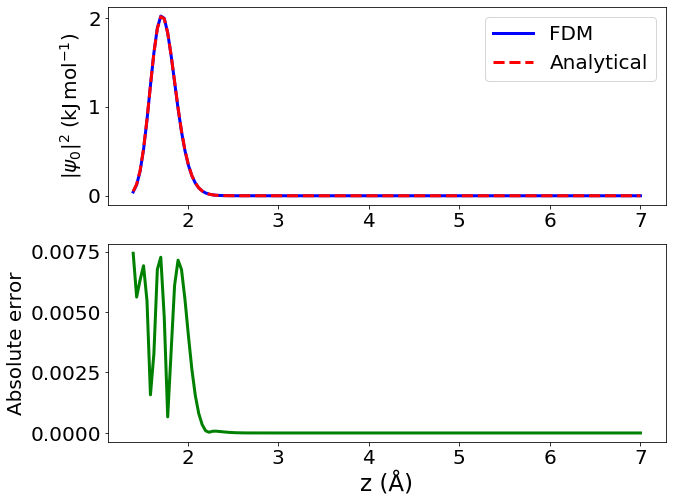

In [32]:
fig, ax = plt.subplots(figsize=(10,8))
#fig, axes = plt.subplots()

plt.subplot (211)
plt.plot(x,WW, color='b',label= "FDM",lw=3)
plt.plot(r,Phi_0, color='r',label= "Analytical",linestyle='--',lw=3)
#plt.xlabel('(z/Å)', fontsize=15)
#plt.ylabel('$\psi$/',fontsize=15)
plt.ylabel(r'$|\psi_0|^2\;(\mathrm{kJ\,mol^{-1}})$', fontsize=20)
plt.legend(loc = 'upper right')
plt.rc('legend', fontsize = 20)
plt.tick_params(labelsize=20)


plt.subplot (212)
plt.plot(x,abs(Phi_0 - WW), color='green',lw=3)
plt.xlabel('z (Å)', fontsize=23)
plt.ylabel('Absolute error',fontsize=20)
#plt.legend(loc = 'upper right')
#plt.rc('legend', fontsize = 10)
plt.tick_params(labelsize=20)

#plt.plot(x,abs(Phi_0 - WW), color='deepskyblue',lw=3)



plt.show()

In [25]:
E1[0]

3.349104168390334

<IPython.core.display.Javascript object>


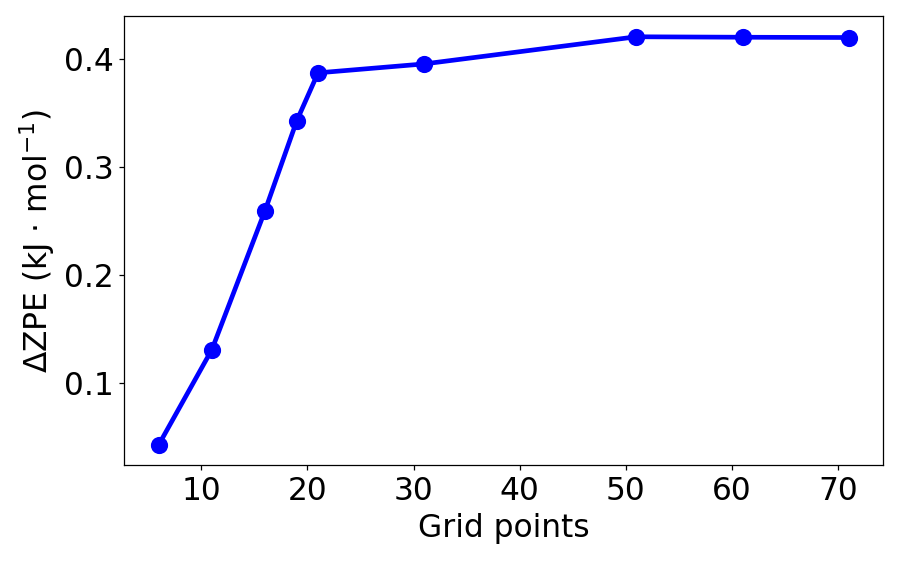

In [2]:
import matplotlib.pyplot as plt
%matplotlib notebook

# Data
Grid_points = [6, 11, 16, 19, 21, 31, 51, 61, 71]
#Delta_ZPE = [0.040285, 0.122518, 0.243172, 0.322596, 0.366117, 0.382437, 0.406896, 0.40658, 0.406279]
Delta_ZPE = [0.042969, 0.130922, 0.25939, 0.342807, 0.387066, 0.395324, 0.420464, 0.420029, 0.419764]

# Plot settings
plt.figure(figsize=(8,5))
plt.plot(Grid_points, Delta_ZPE, marker='o', markersize=10, linewidth=3, color='blue')

plt.tick_params(labelsize=20)
plt.xlabel('Grid points', fontsize=20)
plt.ylabel(r'$\Delta$ZPE (kJ $\cdot$ mol$^{-1}$)',fontsize=20)

#plt.grid(False, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()
